In [2]:
library(CellChat)
library(patchwork)
options(stringsAsFactors = FALSE)

In [3]:
sc <- readRDS("sc_ds_rir.RDS")

In [4]:
table(sc@meta.data$group)


  IR 
9140 

In [5]:
sc@meta.data$cell <- "NA"
sc@meta.data[which(sc@meta.data$celltype%in%c("Neutrophil","Microglia","Myeloid","DC")),]$cell <- "Immune"
sc@meta.data[which(sc@meta.data$celltype%in%c("Rod","HC","VEC","Cone")),]$cell <- "Stroma"
sc@meta.data[which(sc@meta.data$celltype%in%c("AC","RGC","CBC","RBC","Macroglia")),]$cell <- "Neuron"
table(sc@meta.data$cell)


Immune Neuron Stroma 
  3605   3433   2102 

In [6]:
ptm = Sys.time()
data.input = sc@assays$RNA$data
meta = sc@meta.data # a dataframe with rownames containing cell mata data
cell.use <- rownames(meta)
# Subset the input data for CelChat analysis
data.input = data.input[,cell.use]
meta = meta[cell.use, ]
unique(meta$celltype) # check the cell labels

[1] "Microglia"  "Macroglia"  "Cone"       "Neutrophil" "Myeloid"   
 [6] "DC"         "RBC"        "AC"         "CBC"        "RGC"       
[11] "Rod"        "HC"         "VEC"

In [ ]:
cellchat <- createCellChat(object = data.input, meta = meta, group.by = "celltype")

In [8]:
cellchat <- addMeta(cellchat, meta = meta)
cellchat <- setIdent(cellchat, ident.use = "celltype") # set "labels" as default cell identity
levels(cellchat@idents) # show factor levels of the cell labels
groupSize <- as.numeric(table(cellchat@idents)) # number of cells in each cell group

[1] "AC"         "CBC"        "Cone"       "DC"         "HC"        
 [6] "Macroglia"  "Microglia"  "Myeloid"    "Neutrophil" "RBC"       
[11] "RGC"        "Rod"        "VEC"

In [ ]:
CellChatDB <- CellChatDB.mouse # use CellChatDB.mouse if running on mouse data
showDatabaseCategory(CellChatDB)

In [ ]:

dplyr::glimpse(CellChatDB$interaction)

In [11]:

#CellChatDB.use <- subsetDB(CellChatDB, search = "Secreted Signaling", key = "annotation") # use Secreted Signaling分泌信号
CellChatDB.use <- CellChatDB###
# Only uses the Secreted Signaling from CellChatDB v1
#  CellChatDB.use <- subsetDB(CellChatDB, search = list(c("Secreted Signaling"), c("CellChatDB v1")), key = c("annotation", "version"))

# use all CellChatDB except for "Non-protein Signaling" for cell-cell communication analysis
# CellChatDB.use <- subsetDB(CellChatDB)

# use all CellChatDB for cell-cell communication analysis
# CellChatDB.use <- CellChatDB # simply use the default CellChatDB. We do not suggest to use it in this way because CellChatDB v2 includes "Non-protein Signaling" (i.e., metabolic and synaptic signaling). 

cellchat@DB <- CellChatDB.use

In [12]:

cellchat <- subsetData(cellchat) # This step is necessary even if using the whole database
future::plan("multisession", workers = 4) # do parallel
cellchat <- identifyOverExpressedGenes(cellchat)
cellchat <- identifyOverExpressedInteractions(cellchat)

execution.time = Sys.time() - ptm
print(as.numeric(execution.time, units = "secs"))


# cellchat <- projectData(cellchat, PPI.human)

The number of highly variable ligand-receptor pairs used for signaling inference is 2173 
[1] 54.20446


In [13]:
ptm = Sys.time()
cellchat <- computeCommunProb(cellchat, type = "triMean")

triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2026-01-02 19:39:59.429564]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-01-02 19:59:05.068768]"


In [14]:
cellchat <- filterCommunication(cellchat, min.cells = 10)

In [15]:
cellchat <- computeCommunProbPathway(cellchat)

In [16]:
cellchat <- aggregateNet(cellchat)
execution.time = Sys.time() - ptm
print(as.numeric(execution.time, units = "secs"))

[1] 1174.069


In [ ]:
ptm = Sys.time()
groupSize <- as.numeric(table(cellchat@idents))
par(mfrow = c(1,2), xpd=TRUE)
p <- netVisual_circle(cellchat@net$count, vertex.weight = groupSize, weight.scale = T, label.edge= F, title.name = "Number of interactions")
p1<- netVisual_circle(cellchat@net$weight, vertex.weight = groupSize, weight.scale = T, label.edge= F, title.name = "Interaction weights/strength")

In [18]:
pdf("interactions_RIR.pdf")
print(p)
dev.off()
pdf("Interaction_weights_strength_RIR.pdf",width = 10,height = 6)
print(p1)
dev.off()

pdf 
  2

pdf 
  2

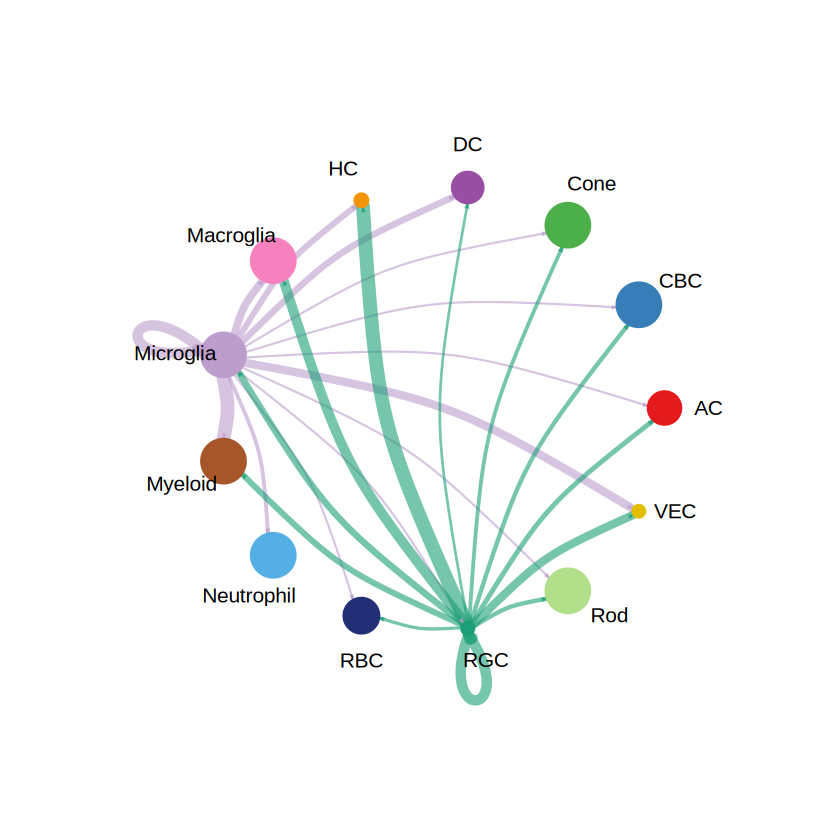

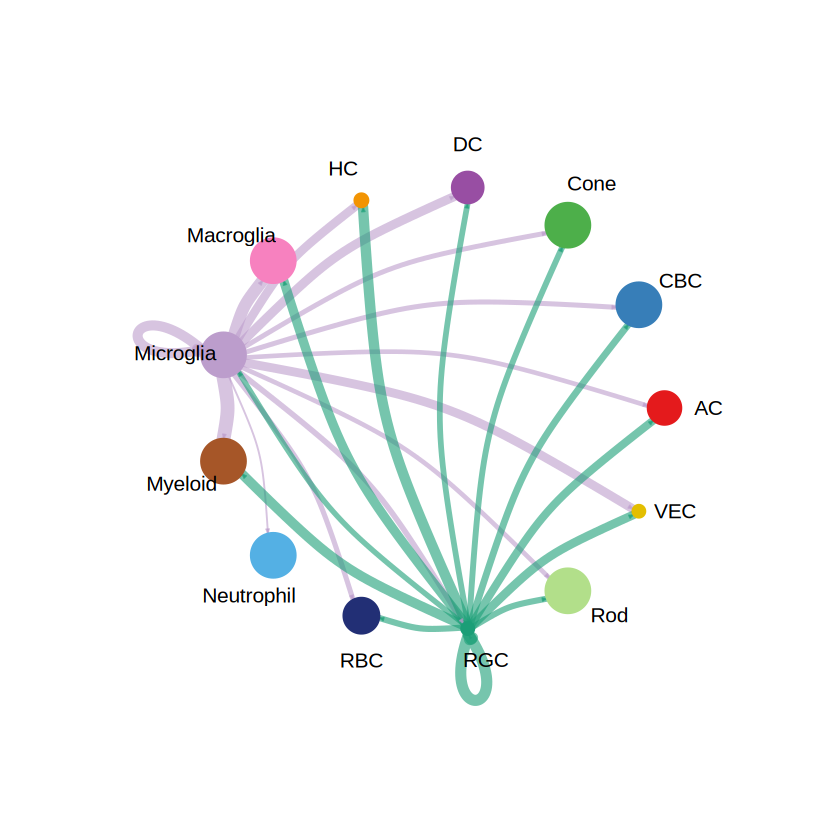

In [19]:
p <- netVisual_circle(cellchat@net$count, vertex.weight = groupSize, weight.scale = T, label.edge= F, title.name = "Number of interactions",sources.use = c("RGC", "Microglia"))
p1<- netVisual_circle(cellchat@net$weight, vertex.weight = groupSize, weight.scale = T, label.edge= F, title.name = "Interaction weights/strength",sources.use = c("RGC", "Microglia"))

In [21]:
mat <- cellchat@net$weight
par(mfrow = c(3,4), xpd=TRUE)
pdf("RIR_net_celtype_ppi.pdf",width = 6,height = 6)
for (i in 1:nrow(mat)) {
  mat2 <- matrix(0, nrow = nrow(mat), ncol = ncol(mat), dimnames = dimnames(mat))
  mat2[i, ] <- mat[i, ]
  netVisual_circle(mat2, vertex.weight = groupSize, weight.scale = T, edge.weight.max = max(mat), label.edge= F, title.name = rownames(mat)[i])
}
dev.off()

pdf 
  2

In [ ]:
df.net <- subsetCommunication(cellchat)
d <- as.data.frame(table(df.net$source))
df1 <- subset(df.net,subset = source=="RGC")
m <- as.data.frame(table(df1$target))
colnames(m) <- c("celltype","RIR")
write.csv(m,"RIR_RGC_source_LR_num.csv")
m

In [24]:
write.csv(df.net,"RIR_cellchat_LR.csv")

In [25]:
df.netp <- subsetCommunication(cellchat, slot.name = "netP")
write.csv(df.netp, "RIR_net_pathway.csv")

In [26]:
colnames(d) <- c("celltype","RIR")
write.csv(d,"./RIR_allLR.csv")

In [30]:
d

celltype,RIR
<fct>,<int>
AC,55
CBC,52
Cone,33
DC,35
HC,104
Macroglia,86
Microglia,114
Myeloid,82
Neutrophil,33


In [31]:
d1 <- as.data.frame(table(df.net$source))
colnames(d1) <- c("celltype","source")
d2 <- as.data.frame(table(df.net$target))
colnames(d2) <- c("celltype","target")
d3 <- cbind(d1,d2)

In [ ]:
d3$LR_num <- d3$source+d3$target
d3
write.csv(d3,"./RIR_allLR.csv")

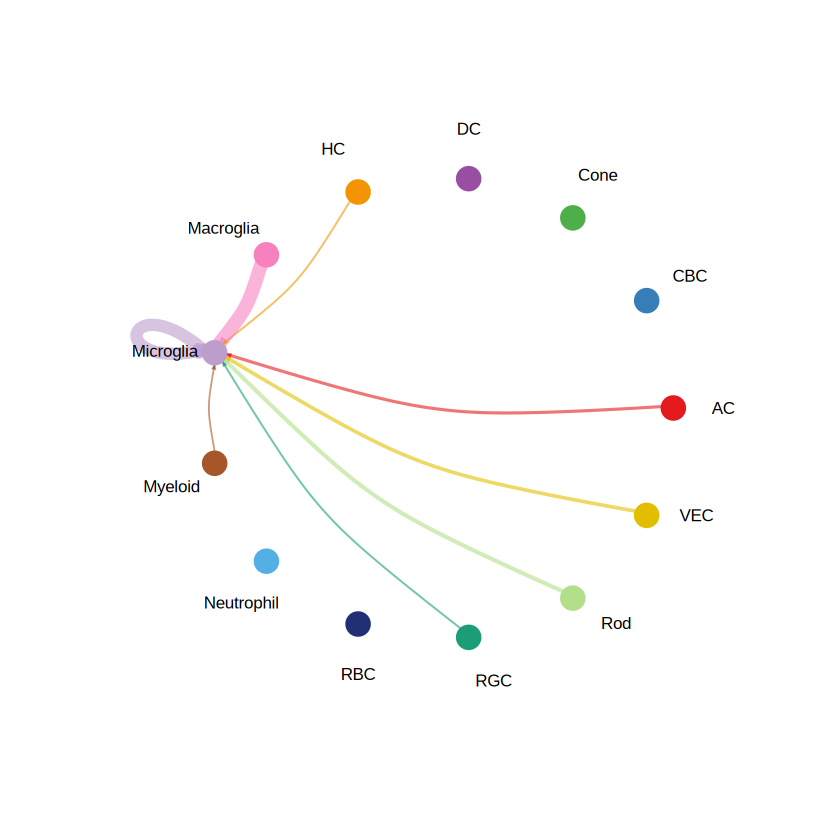

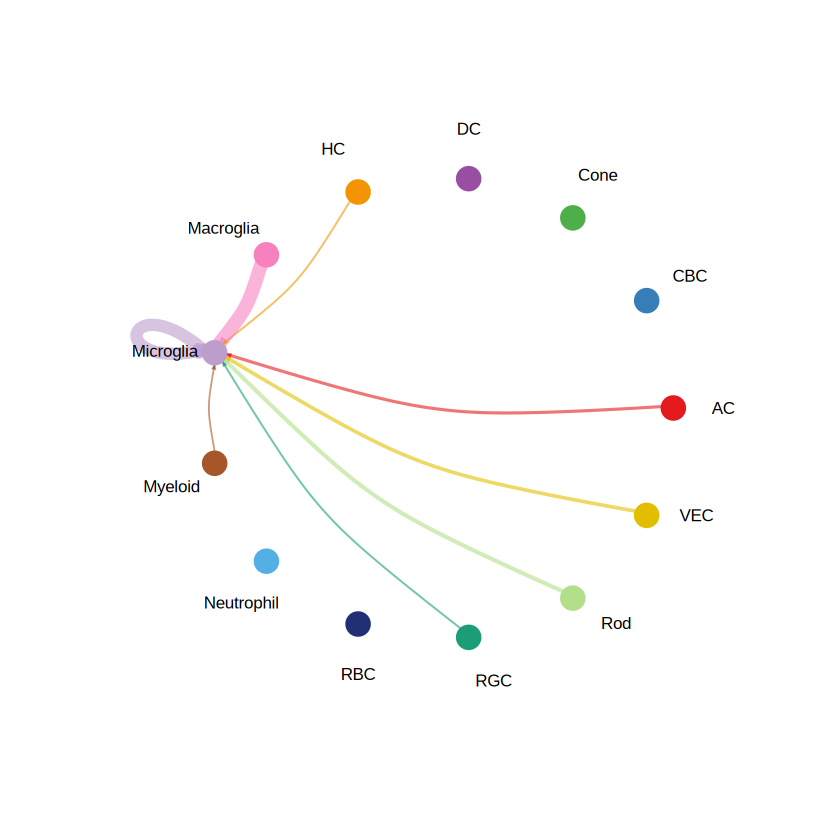

In [32]:
pathways.show <- c("ApoE") 
# Hierarchy plot
# Here we define `vertex.receive` so that the left portion of the hierarchy plot shows signaling to fibroblast and the right portion shows signaling to immune cells 
vertex.receiver = seq(1,4) # a numeric vector. 
netVisual_aggregate(cellchat, signaling = pathways.show,  vertex.receiver = vertex.receiver)
# Circle plot
par(mfrow=c(1,1))
p <- netVisual_aggregate(cellchat, signaling = pathways.show, layout = "circle")

pdf 
  2

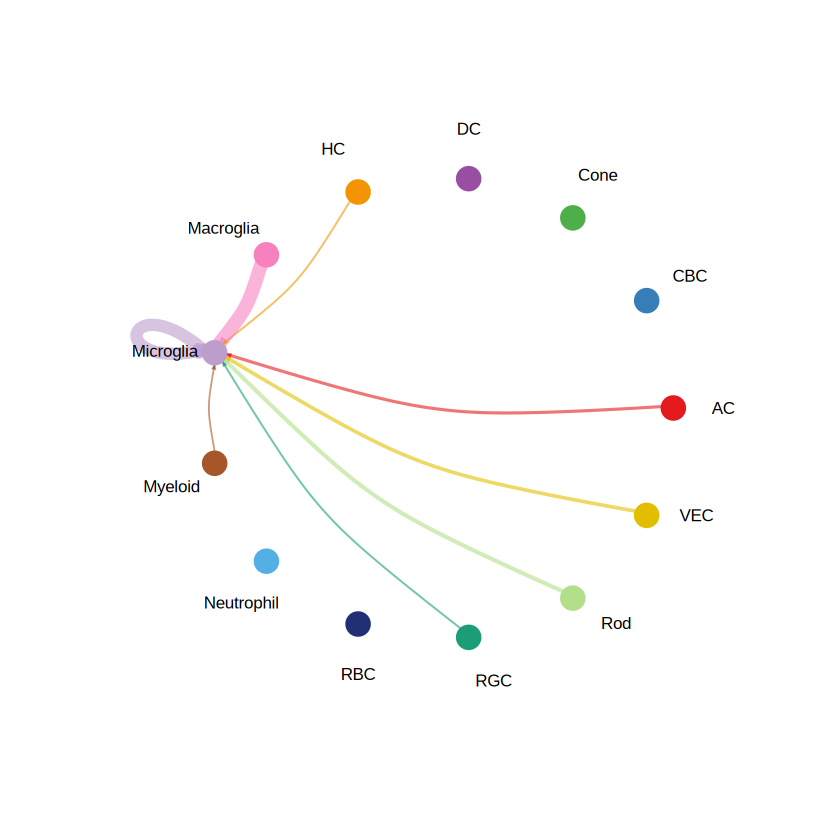

In [34]:
pdf("ApoE_network_allcell.pdf",width = 6,height = 6)
print(p)
dev.off()
p

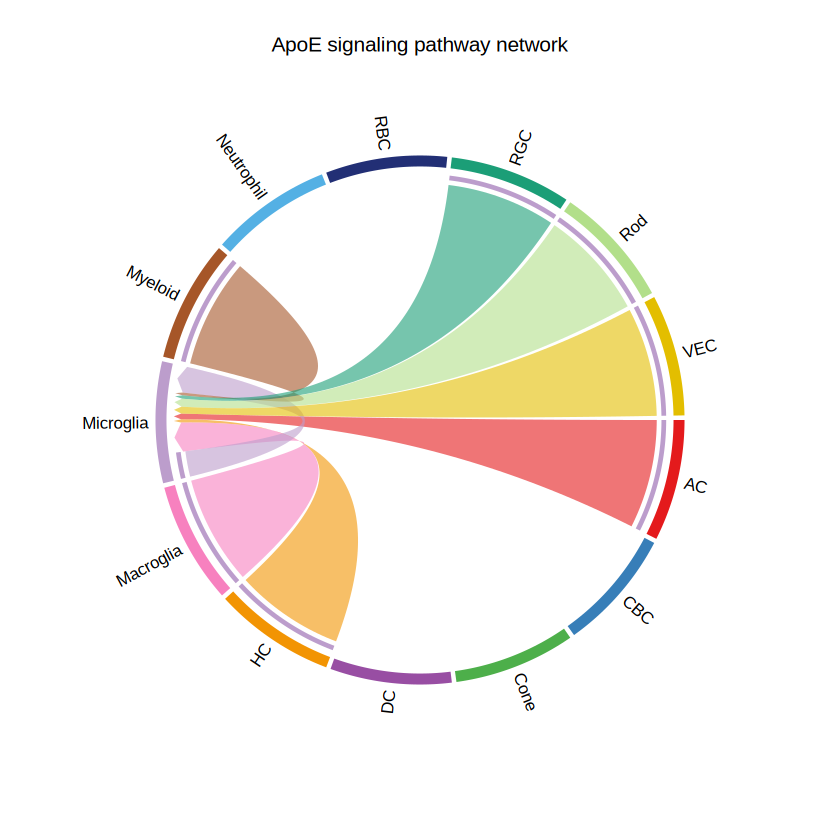

pdf 
  2

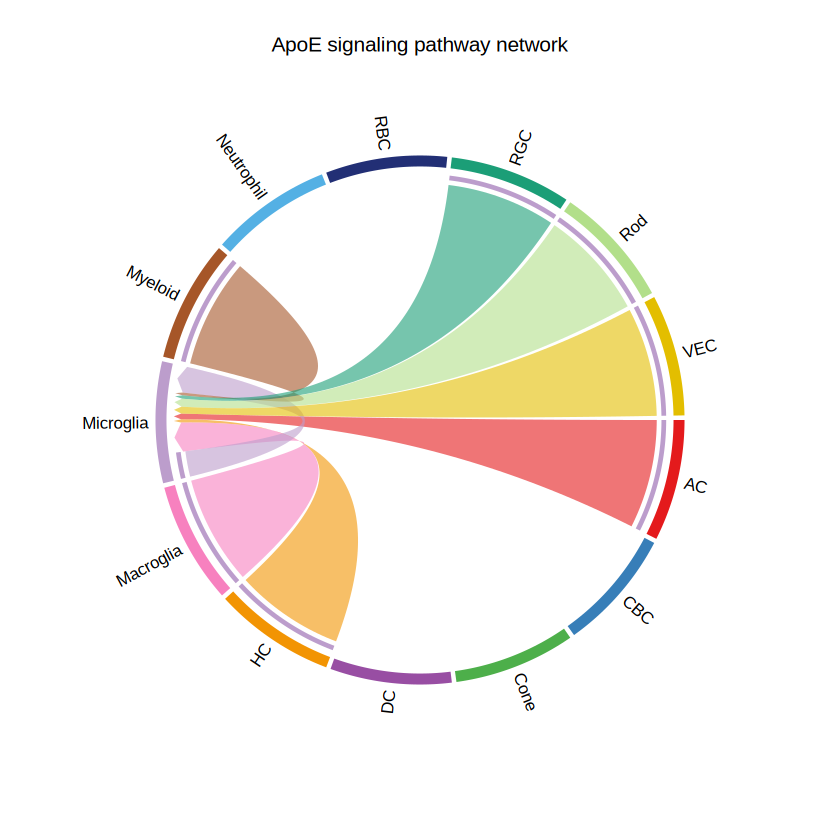

In [39]:
# Chord diagram
par(mfrow=c(1,1))
p <- netVisual_aggregate(cellchat, signaling = pathways.show, layout = "chord")
p
pdf("S3B.pdf",width = 6,height = 6)
print(p)
dev.off()